# MPRM(Mixed Population Representation Model):evaluation figures

Reproduces the evaluation figures from a completed `MPAT train` run. 
Every figure reads a CSV or JSON written by the pipeline.

**Run order:** Setup → Paths → any figure cell. 

| Figure | Source file | Shows |
|---|---|---|
| 1 | `metrics_all.json` | Train / validation / test metrics with bootstrap CIs |
| 2 | `leave_one_ratio_predictions.csv` | LORO predicted vs observed titers |
| 3 | `leave_one_ratio_predictions.csv` | Absolute error and dilution accuracy by titer level |
| 4 | `leave_one_ratio_predictions.csv` | Cumulative accuracy: predictions within N dilutions |
| 5 | `leave_one_ratio_metrics.csv` | Per-fold performance radar |
| 6 | `predictions_test.csv` | Independent test set predicted vs observed |

## Setup

In [ ]:
# Imports, plot style and the shared colour scheme
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

COLORS = {
    "train":  "#9FB6CD",
    "val":    "#2E86AB",
    "test":   "#C0504D",
    "line":   "#566573",
    "fill":   "#2E86AB",
    "accent": "#C0504D",
}

FOLD_COLORS = ["#1B4F72", "#2E86AB", "#16A085", "#27AE60", "#D4AC0D",
               "#CA6F1E", "#884EA0", "#566573", "#1C2833", "#117A65"]

TITER_CMAP = LinearSegmentedColormap.from_list(
    "titer", ["#EDE7F2", "#9BB8D3", "#3E8EA8", "#118C7E", "#1A6B4A", "#0B4A2F"])

## Configure paths and file names here

In [ ]:
# Point RESULTS at the --output_dir used for `MPAT train`
RESULTS = Path("results")
FIGURES = RESULTS / "figures"
FMT, DPI = "png", 300            # select which format to save figures in: "png", "pdf" or "svg"

CV = RESULTS / "cross_validation"
FIGURES.mkdir(parents=True, exist_ok=True)


def save(fig, stem):
    """Write a figure into FIGURES and report the path."""
    fig.savefig(FIGURES / f"{stem}.{FMT}", dpi=DPI)
    print(f"saved {FIGURES / stem}.{FMT}")


def load_json(path):
    path = Path(path)
    return json.loads(path.read_text()) if path.exists() else None


def load_csv(path):
    path = Path(path)
    return pd.read_csv(path) if path.exists() else None


metrics   = load_json(RESULTS / "metrics_all.json")
loro      = load_csv(CV / "leave_one_ratio_predictions.csv")
loro_fold = load_csv(CV / "leave_one_ratio_metrics.csv")
test_pred = load_csv(RESULTS / "predictions_test.csv")


for name, obj in [("metrics_all.json", metrics),
                  ("LORO predictions", loro),
                  ("LORO fold metrics", loro_fold),
                  ("test predictions", test_pred)]:
    status = "missing" if obj is None else (
        f"{len(obj)} rows" if isinstance(obj, pd.DataFrame) else "loaded")
    print(f"{name:20s} {status}")

metrics_all.json     loaded
LORO predictions     250 rows
LORO fold metrics    11 rows
test predictions     25 rows


## Figure 1: Train, validation and test metrics

Six metrics per split with 95% bootstrap confidence intervals where the pipeline recorded
them.

saved results\figures\fig1_split_metrics.png


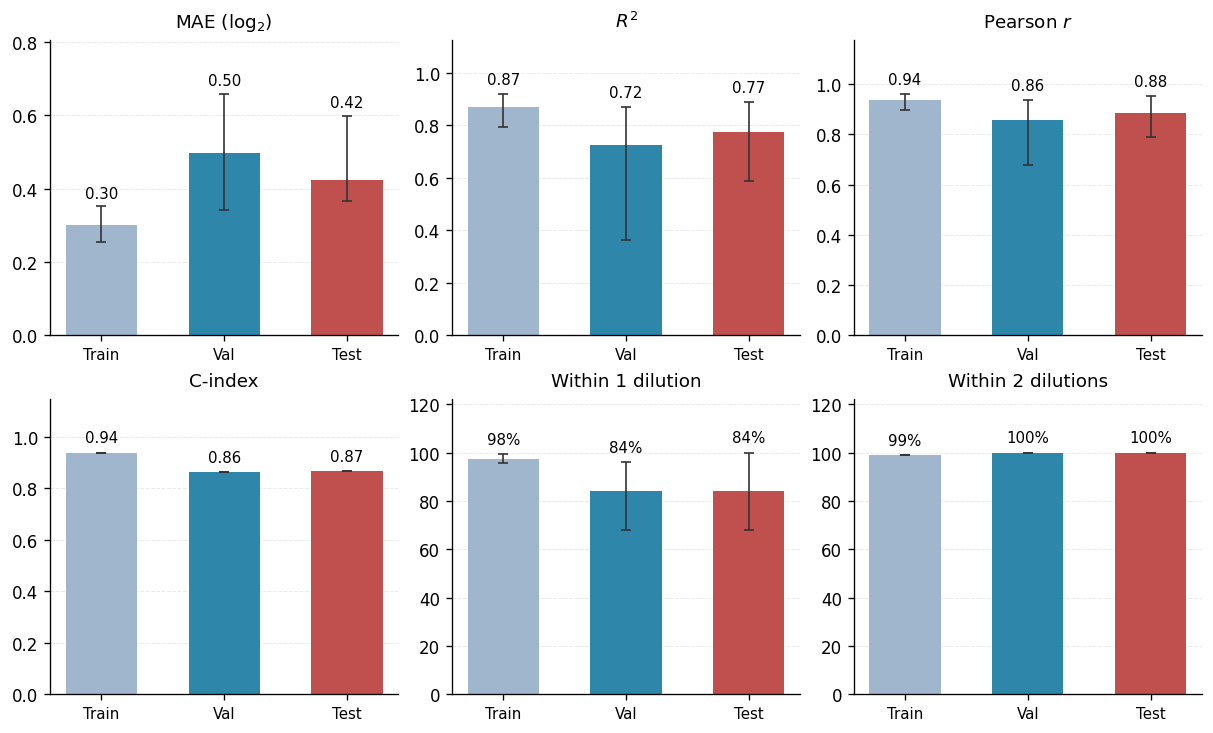

In [3]:
SPLITS = ["train", "val", "test"]
PANELS = [
    ("mae_log2",           "MAE (log$_2$)",     False),
    ("r2",                 "$R^2$",             False),
    ("pearson_r",          "Pearson $r$",       False),
    ("concordance_index",  "C-index",           False),
    ("within_1_dilution",  "Within 1 dilution", True),
    ("within_2_dilutions", "Within 2 dilutions", True),
]

fig, axes = plt.subplots(2, 3, figsize=(10, 6), constrained_layout=True)

for ax, (key, title, as_pct) in zip(axes.ravel(), PANELS):
    scale = 100 if as_pct else 1

    # point estimate and asymmetric CI half-widths for each split
    values, lo, hi = [], [], []
    for s in SPLITS:
        m = metrics[s]
        v = float(m.get(key, np.nan))
        ci = m.get("bootstrap_ci", {}).get(key)
        values.append(v * scale)
        lo.append(max(v - ci["ci_lower"], 0.0) * scale if ci else 0.0)
        hi.append(max(ci["ci_upper"] - v, 0.0) * scale if ci else 0.0)

    values, lo, hi = np.array(values), np.array(lo), np.array(hi)
    xpos = np.arange(len(SPLITS))

    ax.bar(xpos, values, width=0.58, color=[COLORS[s] for s in SPLITS], zorder=2)
    ax.errorbar(xpos, values, yerr=np.vstack([lo, hi]), fmt="none",
                ecolor="#333333", elinewidth=1.0, capsize=3, zorder=3)

    # value label sits above the upper CI whisker
    headroom = max(values.max() * 0.03, 0.01)
    for xi, v, h in zip(xpos, values, hi):
        ax.text(xi, v + h + headroom, f"{v:.0f}%" if as_pct else f"{v:.2f}",
                ha="center", va="bottom", fontsize=9)

    ax.set_xticks(xpos)
    ax.set_xticklabels(["Train", "Val", "Test"], fontsize=9)
    ax.set_ylim(0, (values + hi).max() * 1.22)
    ax.set_title(title, fontsize=11, pad=8)
    ax.grid(axis="y", ls="--", lw=0.6, alpha=0.25, zorder=0)

save(fig, "fig1_split_metrics")

## Figure 2: LORO predicted vs observed

Every point is one held-out observation from leave-one-ratio-out cross-validation, so no
point's K:T:I composition was seen during training. The shaded band is one two-fold
dilution.

saved results\figures\fig2_loro_scatter.png


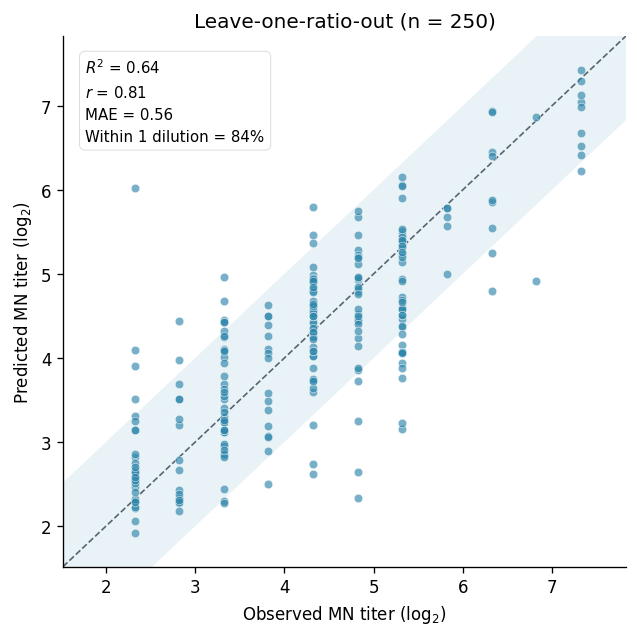

In [4]:
y = loro["log2_titer"].to_numpy(float)
p = loro["pred_log2_titer"].to_numpy(float)

mae = np.abs(p - y).mean()
r2 = 1 - ((p - y) ** 2).sum() / ((y - y.mean()) ** 2).sum()
r = np.corrcoef(y, p)[0, 1]
w1 = (np.abs(p - y) <= 1).mean()

lim = (min(y.min(), p.min()) - 0.4, max(y.max(), p.max()) + 0.4)

fig, ax = plt.subplots(figsize=(5.2, 5.2), constrained_layout=True)

# +/- 1 dilution tolerance band around the identity line
ax.fill_between(lim, [lim[0] - 1, lim[1] - 1], [lim[0] + 1, lim[1] + 1],
                color=COLORS["fill"], alpha=0.10, lw=0, zorder=0)
ax.plot(lim, lim, ls="--", lw=1, color=COLORS["line"], zorder=1)
ax.scatter(y, p, s=26, alpha=0.65, color=COLORS["fill"],
           edgecolor="white", linewidth=0.4, zorder=2)

ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel("Observed MN titer (log$_2$)")
ax.set_ylabel("Predicted MN titer (log$_2$)")
ax.set_title(f"Leave-one-ratio-out (n = {len(y)})")
ax.text(0.04, 0.96,
        f"$R^2$ = {r2:.2f}\n$r$ = {r:.2f}\nMAE = {mae:.2f}\n"
        f"Within 1 dilution = {w1 * 100:.0f}%",
        transform=ax.transAxes, va="top", fontsize=9, linespacing=1.6,
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#DDDDDD", lw=0.6))

save(fig, "fig2_loro_scatter")

## Figure 3: Error and dilution accuracy by titer level

Left figure shows the distribution of absolute error at each observed titer, with the 1- and 2-dilution thresholds marked. 
Right figure shows the percentage of predictions falling within each threshold at that titer. 

saved results\figures\fig3_error_by_titer.png


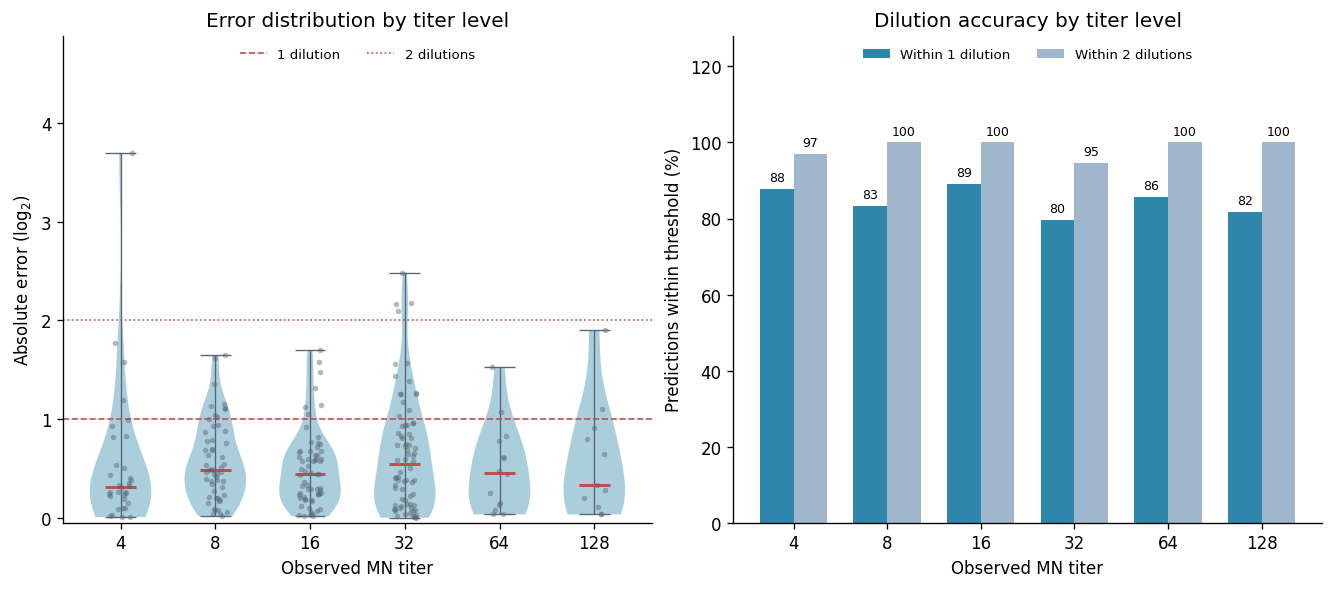

In [5]:
d = loro.copy()
d["abs_error"] = (d["pred_log2_titer"] - d["log2_titer"]).abs()

levels = sorted(d["obs_titer_2fold"].dropna().unique())
labels = [str(int(t)) for t in levels]
groups = [d.loc[d["obs_titer_2fold"] == t, "abs_error"].to_numpy() for t in levels]
w1 = [float((g <= 1).mean() * 100) for g in groups]
w2 = [float((g <= 2).mean() * 100) for g in groups]
x = np.arange(len(levels))

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11, 4.8), constrained_layout=True)

# -- left: error distribution, violin plus jittered points ------------------
parts = ax.violinplot(groups, positions=x, widths=0.65, showmedians=True)
for body in parts["bodies"]:
    body.set_facecolor(COLORS["fill"])
    body.set_alpha(0.40)
parts["cmedians"].set_color(COLORS["accent"])
parts["cmedians"].set_linewidth(1.8)
for k in ("cbars", "cmins", "cmaxes"):
    parts[k].set_color(COLORS["line"])
    parts[k].set_linewidth(0.8)

rng = np.random.default_rng(0)
for pos, vals in zip(x, groups):
    ax.scatter(pos + rng.uniform(-0.12, 0.12, len(vals)), vals,
               s=11, alpha=0.45, color=COLORS["line"], lw=0, zorder=3)

ax.axhline(1, color=COLORS["accent"], ls="--", lw=1, label="1 dilution")
ax.axhline(2, color=COLORS["accent"], ls=":", lw=1, label="2 dilutions")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(-0.05, max(g.max() for g in groups) * 1.32)
ax.set_xlabel("Observed MN titer")
ax.set_ylabel("Absolute error (log$_2$)")
ax.set_title("Error distribution by titer level")
ax.legend(fontsize=8, frameon=False, loc="upper center", ncol=2)

# -- right: paired bars, one per threshold ----------------------------------
bw = 0.36
ax2.bar(x - bw / 2, w1, width=bw, color=COLORS["val"], label="Within 1 dilution")
ax2.bar(x + bw / 2, w2, width=bw, color=COLORS["train"], label="Within 2 dilutions")
for xi, (v1, v2) in enumerate(zip(w1, w2)):
    ax2.text(xi - bw / 2, v1 + 2, f"{v1:.0f}", ha="center", fontsize=7.5)
    ax2.text(xi + bw / 2, v2 + 2, f"{v2:.0f}", ha="center", fontsize=7.5)

ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_ylim(0, 128)
ax2.set_xlabel("Observed MN titer")
ax2.set_ylabel("Predictions within threshold (%)")
ax2.set_title("Dilution accuracy by titer level")
ax2.legend(fontsize=8, frameon=False, loc="upper center", ncol=2)

save(fig, "fig3_error_by_titer")

## Figure 4: Predictions within N dilutions

Fraction of predictions within increasing log2-dilution tolerances.
A plateau before two dilutions indicates that large prediction errors are rare.

saved results\figures\fig4_within_n_dilutions.png


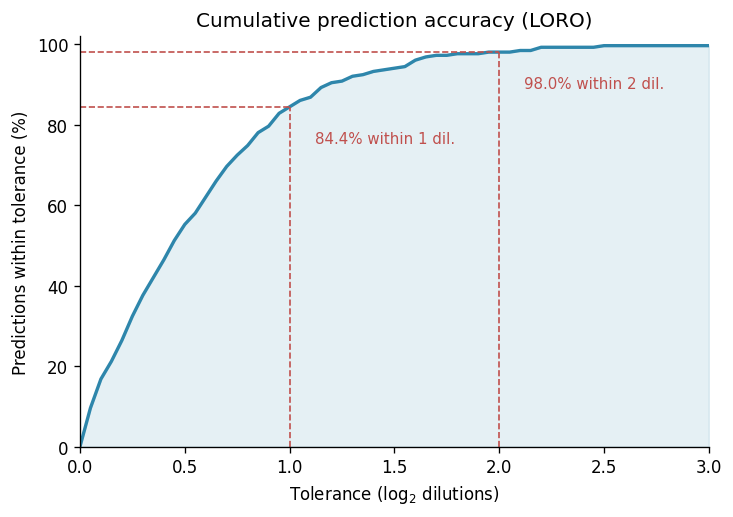

In [6]:
err = (loro["pred_log2_titer"] - loro["log2_titer"]).abs().to_numpy()

thresholds = np.arange(0, 3.01, 0.05)
frac = np.array([(err <= t).mean() for t in thresholds]) * 100

fig, ax = plt.subplots(figsize=(6, 4.2), constrained_layout=True)
ax.plot(thresholds, frac, color=COLORS["fill"], lw=2)
ax.fill_between(thresholds, 0, frac, color=COLORS["fill"], alpha=0.12)

# drop lines at the two conventional dilution thresholds
for t in (1, 2):
    v = (err <= t).mean() * 100
    ax.plot([t, t], [0, v], ls="--", lw=1, color=COLORS["accent"])
    ax.plot([0, t], [v, v], ls="--", lw=1, color=COLORS["accent"])
    ax.annotate(f"{v:.1f}% within {t} dil.", xy=(t, v), xytext=(t + 0.12, v - 9),
                fontsize=9, color=COLORS["accent"])

ax.set_xlim(0, 3)
ax.set_ylim(0, 102)
ax.set_xlabel("Tolerance (log$_2$ dilutions)")
ax.set_ylabel("Predictions within tolerance (%)")
ax.set_title("Cumulative prediction accuracy (LORO)")

save(fig, "fig4_within_n_dilutions")

## Figure 5: Per-fold performance radar
This radar shows the performance metrics for each held out leave one ratio conditions

saved results\figures\fig5_performance_radar.png


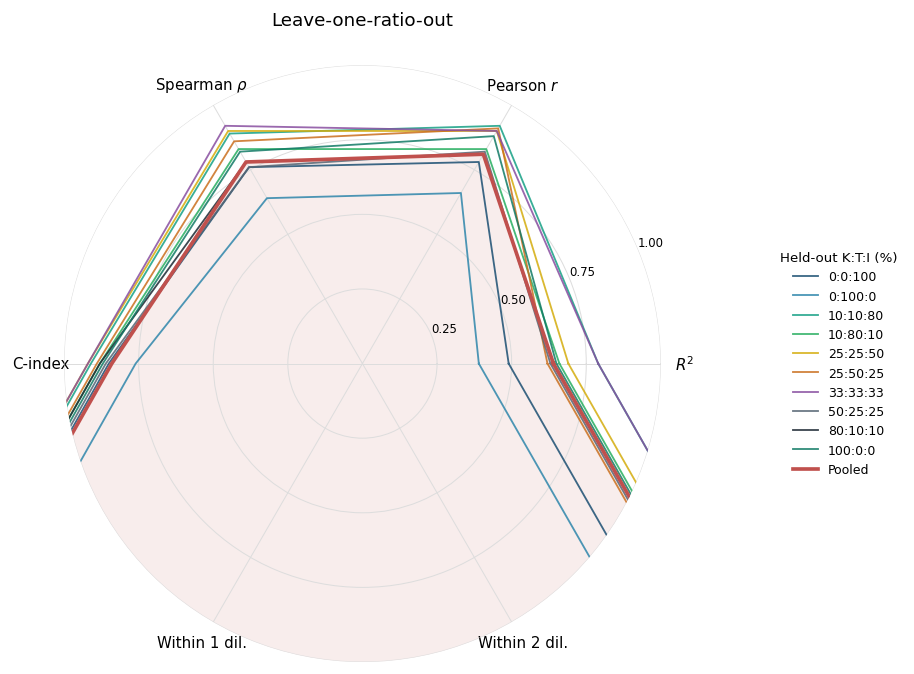

In [7]:
KEYS = ["R2", "pearson", "spearman", "c_index",
        "within_1_dilution", "within_2_dilutions"]
LABELS = ["$R^2$", "Pearson $r$", "Spearman $\\rho$", "C-index",
          "Within 1 dil.", "Within 2 dil."]
ANGLES = [n / len(KEYS) * 2 * np.pi for n in range(len(KEYS))] + [0.0]


def ratio_label(s):
    """'0.80__0.10__0.10' -> '80:10:10'."""
    parts = str(s).split("__")
    if len(parts) != 3:
        return str(s)
    return ":".join(f"{float(v) * 100:.0f}" for v in parts)


def closed(row):
    """Metric values for one row, with the first value repeated to close the polygon."""
    v = [float(row[k]) if pd.notna(row[k]) else 0.0 for k in KEYS]
    return v + [v[0]]


fig, ax = plt.subplots(figsize=(7.5, 6), subplot_kw=dict(polar=True),
                       constrained_layout=True)

folds = loro_fold[loro_fold["fold_id"] != "overall"].sort_values("heldout_group")
for i, (_, row) in enumerate(folds.iterrows()):
    ax.plot(ANGLES, closed(row), color=FOLD_COLORS[i % len(FOLD_COLORS)],
            lw=1.1, alpha=0.85, label=ratio_label(row["heldout_group"]))

pooled = loro_fold[loro_fold["fold_id"] == "overall"]
if len(pooled):
    v = closed(pooled.iloc[0])
    ax.plot(ANGLES, v, color=COLORS["accent"], lw=2.2, zorder=10, label="Pooled")
    ax.fill(ANGLES, v, color=COLORS["accent"], alpha=0.10)

ax.set_xticks(ANGLES[:-1])
ax.set_xticklabels(LABELS, size=9)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.50, 0.75, 1.00])
ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], size=7)
ax.spines["polar"].set_visible(False)
ax.grid(color="#DDDDDD", lw=0.6)
ax.set_title("Leave-one-ratio-out", pad=24, fontsize=11)
ax.legend(loc="center left", bbox_to_anchor=(1.18, 0.5), fontsize=7.5,
          frameon=False, title="Held-out K:T:I (%)", title_fontsize=8)

save(fig, "fig5_performance_radar")

84.0
saved results\figures\fig6_test_scatter.png


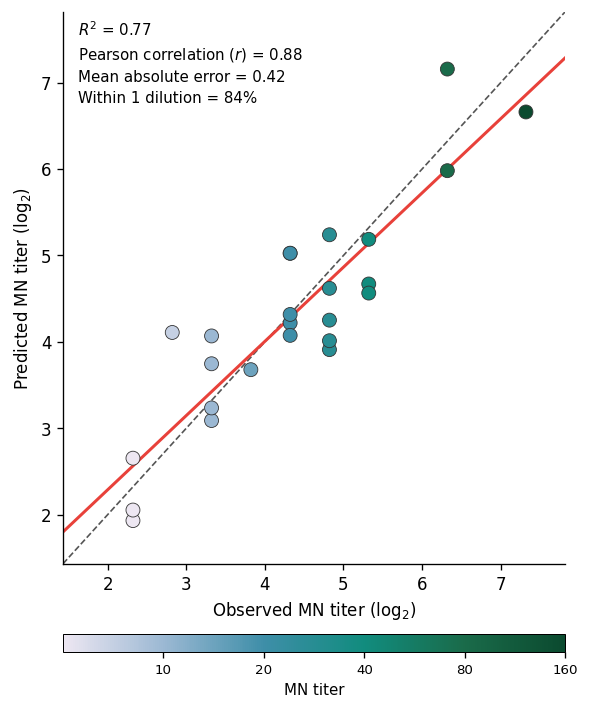

In [ ]:
# metrics: metrics_all.json,
m = (metrics or {}).get("test") or load_json(RESULTS / "metrics_test.json")
print(m['within_1_dilution'] * 100)
if test_pred is None:
    test_pred = load_csv(RESULTS / "predictions_test.csv")

if m is None:
    raise FileNotFoundError(f"No test metrics found in {RESULTS}")

yt = test_pred["log2_titer"].to_numpy(float)
pt = test_pred["pred_log2_titer"].to_numpy(float)

lim = (min(yt.min(), pt.min()) - 0.5, max(yt.max(), pt.max()) + 0.5)

fig, ax = plt.subplots(figsize=(4.8, 5.8), constrained_layout=True)

ax.plot(lim, lim, ls="--", lw=1, color="#555555", zorder=1)

slope, intercept = np.polyfit(yt, pt, 1)
ax.plot(np.array(lim), slope * np.array(lim) + intercept,
        color="#E8413A", lw=1.8, zorder=2)

sc = ax.scatter(yt, pt, c=yt, cmap=TITER_CMAP, s=70,
                edgecolor="#333333", linewidth=0.5, zorder=3)

ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel("Observed MN titer (log$_2$)")
ax.set_ylabel("Predicted MN titer (log$_2$)")
ax.text(0.03, 0.985,
        f"$R^2$ = {m['r2']:.2f}\n"
        f"Pearson correlation ($r$) = {m['pearson_r']:.2f}\n"
        f"Mean absolute error = {m['mae_log2']:.2f}\n"
        f"Within 1 dilution = {m['within_1_dilution'] * 100:.0f}%",
        transform=ax.transAxes, va="top", ha="left", fontsize=9, linespacing=1.5)


ticks = [t for t in (10, 20, 40, 80, 160, 320, 640)
         if yt.min() <= np.log2(t) <= yt.max()]
cbar = fig.colorbar(sc, ax=ax, orientation="horizontal",
                    fraction=0.05, pad=0.02, aspect=28)
cbar.set_ticks([np.log2(t) for t in ticks])
cbar.set_ticklabels([str(t) for t in ticks], fontsize=8)
cbar.set_label("MN titer", fontsize=9)
cbar.outline.set_linewidth(0.6)

save(fig, "fig6_test_scatter")